In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('darkgrid')

In [3]:
df = pd.read_excel('data/Suspension Data Labeling.xlsx', sheet_name='Test_Labels')

In [4]:
df

,Test #,Total number of dropped drops,Number of detached small droplets during Spreading,Droplet Receding,Rim merging or Central jet ejecting,Number of detached small droplets during Receding or Rim merging,Rebound,Number of detached droplets during Rebound,Final droplets count,Comments
0,NaN,"Общее количество капель, упавших сверху. Обычн...","Количество мелких капель, вылетевших из ламелы...","Наличие (1,2), отсутствие - 0 видимого сбора к...","Наличие (1,2), отсутствие - 0 явного объединен...","Количество мелких капель, отделяющихся от обод...","Наличие (1,2), отсутствие - 0 отскока капли по...","Количество капель, отделяющихся от обратной ве...","Общее количество капель на подложке, явно отде...",NaN
1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Calibration test
2,2.0,1.0,many,0.0,0.0,0.0,0.0,0.0,2.0,NaN
3,3.0,1.0,many,0.0,0.0,0.0,0.0,0.0,1.0,NaN
4,4.0,1.0,many,0.0,0.0,0.0,0.0,0.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...
396,396.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
397,397.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
398,398.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
399,399.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# удаляем лишние строки
df = df.iloc[2:401-5, :]

In [6]:
df.dtypes

Test #                                                              float64
Total number of dropped drops                                        object
Number of detached small droplets during Spreading                   object
Droplet Receding                                                     object
Rim merging or Central jet ejecting                                  object
Number of detached small droplets during Receding or Rim merging     object
Rebound                                                              object
Number of detached droplets during Rebound                           object
Final droplets count                                                 object
Comments                                                             object
dtype: object

In [7]:
df.isna().sum()

Test #                                                                0
Total number of dropped drops                                         1
Number of detached small droplets during Spreading                    0
Droplet Receding                                                      0
Rim merging or Central jet ejecting                                   0
Number of detached small droplets during Receding or Rim merging      1
Rebound                                                               0
Number of detached droplets during Rebound                            0
Final droplets count                                                  0
Comments                                                            386
dtype: int64

In [8]:
# уникальные значения в каждом столбце
for column in df.columns:
    if column == 'Test #':
        continue
    print(column)
    print(df[column].unique())
    print()

Total number of dropped drops
[1.0 2.0 '-' 3.0 4.0 nan]

Number of detached small droplets during Spreading
['many' '-' 4.0 1.0 0.0 2.0 5.0 3.0 7.0]

Droplet Receding
[0.0 1.0 '-' 2.0]

Rim merging or Central jet ejecting
[0.0 '-' 1.0 2.0]

Number of detached small droplets during Receding or Rim merging
[0.0 '-' 'many' 4.0 3.0 2.0 1.0 nan]

Rebound
[0.0 '-' 1.0 2.0]

Number of detached droplets during Rebound
[0.0 '-' 1.0 3.0 2.0]

Final droplets count
[2.0 1.0 7.0 6.0 5.0 'many' 0.0 3.0 4.0]

Comments
[nan 'C+'
 'A - ?. Что не так с A? Если про количество упавших капель B, то всё верно! В колонке I я бы поставил 2 капли, так как на подложке в итоге 2 отдельных капли'
 'С - Вылетело несколько очень мелких капель' 'Видео отсутствует'
 'На видео отсутствует момент падения капли']



In [9]:
df_temp = df.copy()
df_temp.drop(columns='Test #', inplace=True)

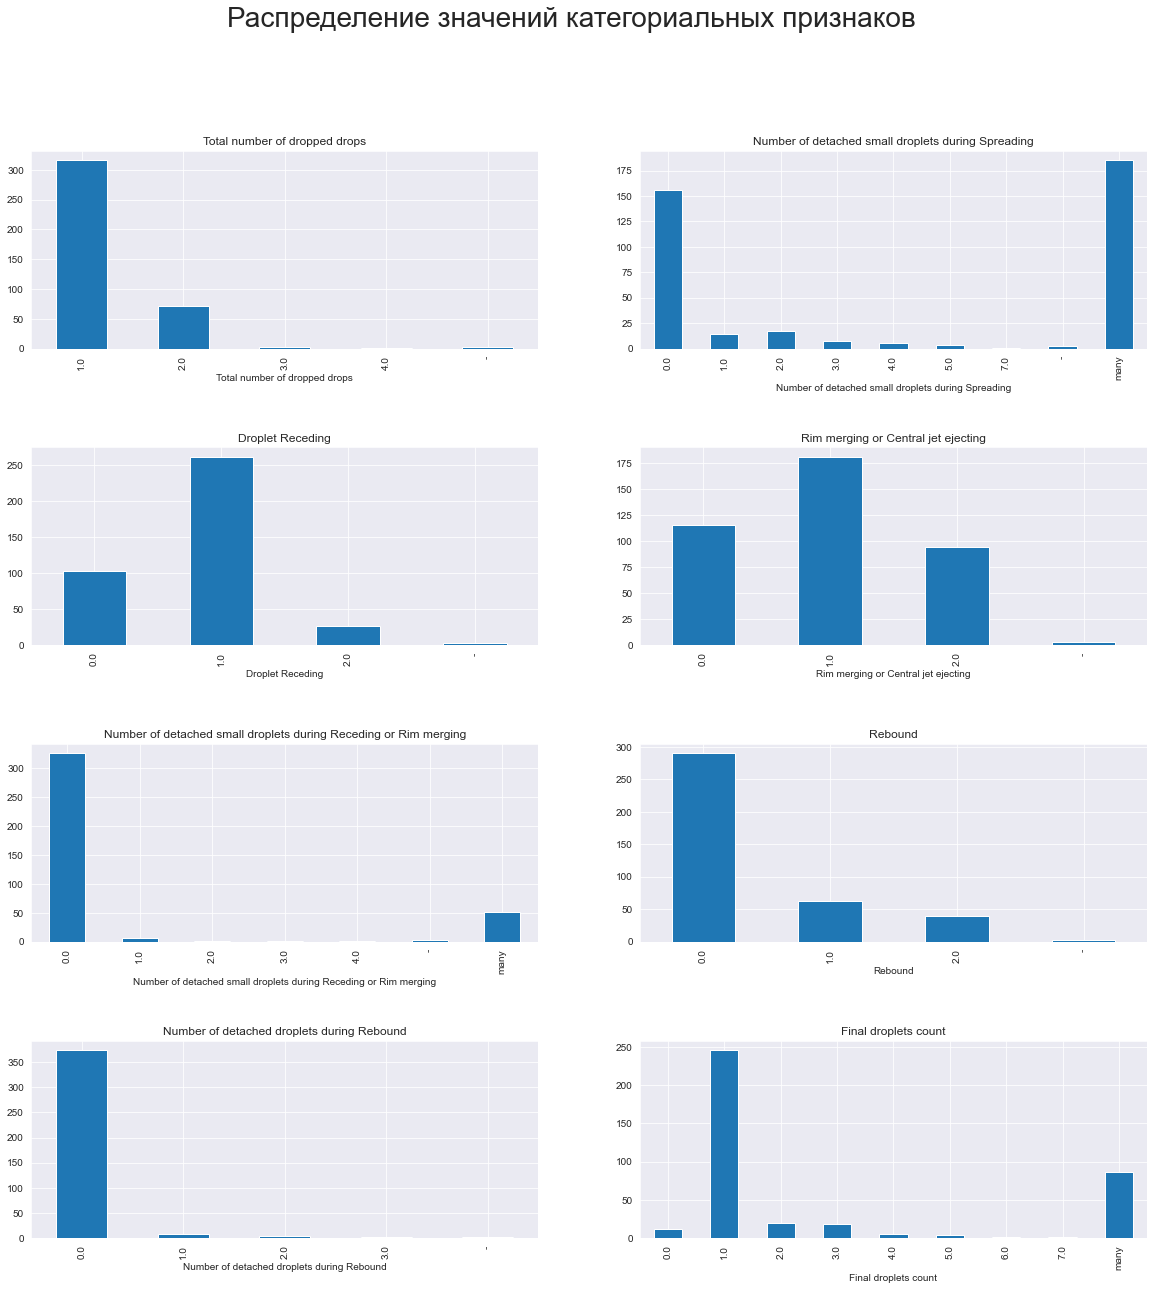

In [10]:
fig, axs = plt.subplots(4, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle('Распределение значений категориальных признаков', fontsize=28)
for column, ax in zip(df_temp.columns, axs.ravel()):
    df_temp[column] = df_temp[column].astype(str)
    df_grouped = df.groupby(by=column).size()
    df_grouped.plot.bar(ax=ax)
    ax.set_title(column)
plt.show()

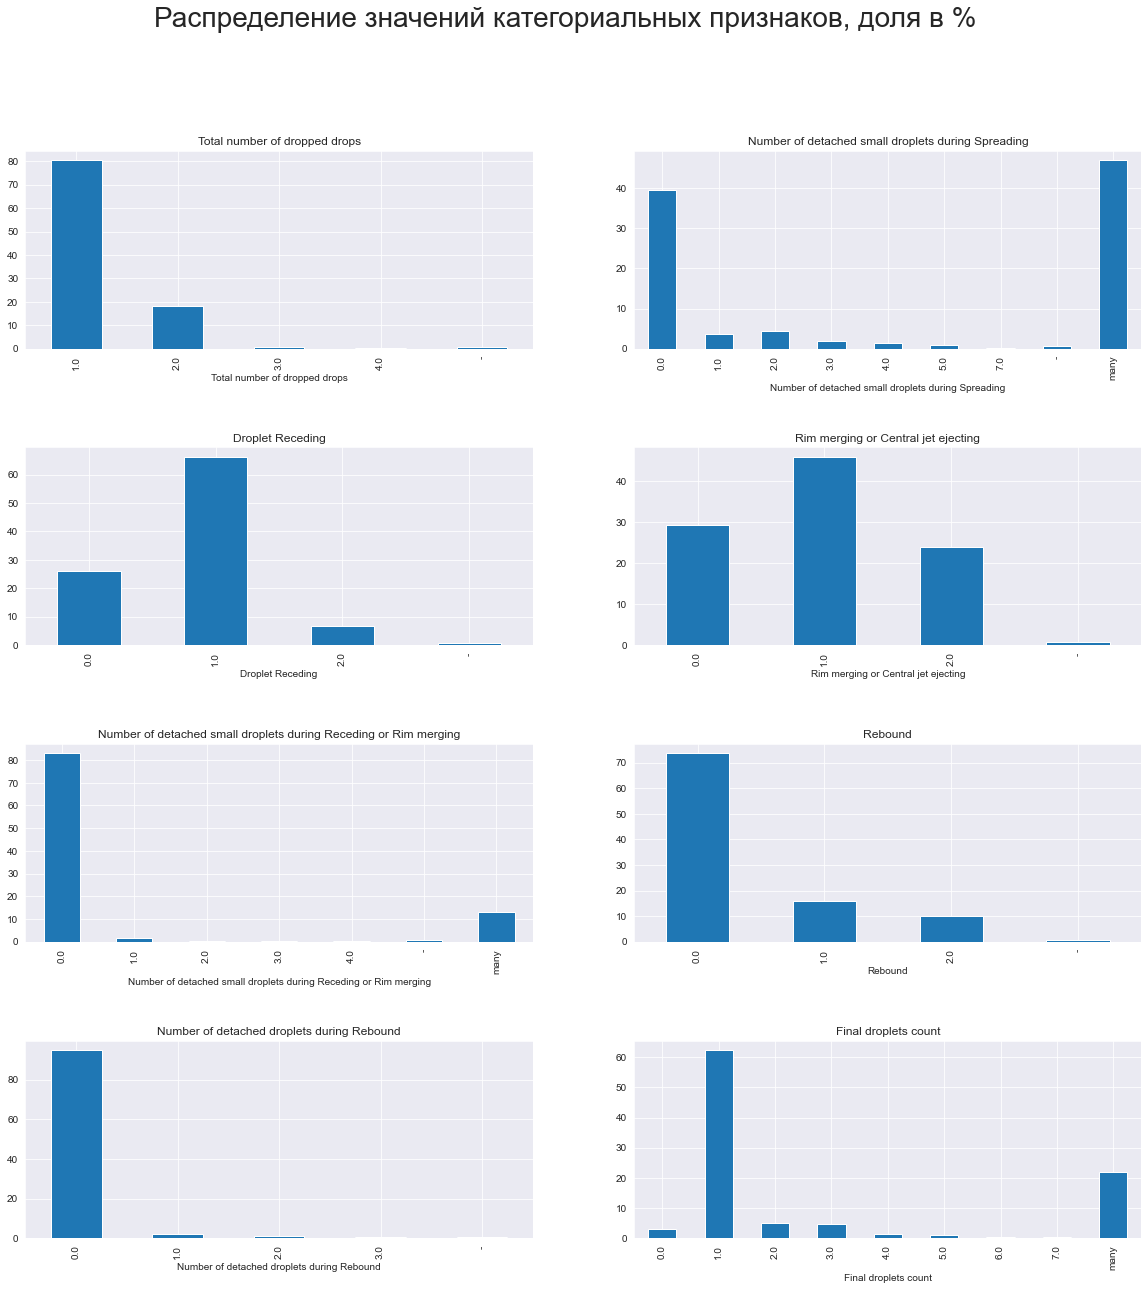

In [11]:
fig, axs = plt.subplots(4, 2, figsize=(20, 20))
plt.subplots_adjust(hspace=0.5)
fig.suptitle('Распределение значений категориальных признаков, доля в %', fontsize=28)
for column, ax in zip(df_temp.columns, axs.ravel()):
    df_grouped = df.groupby(by=column).size()
    ((df_grouped / df_grouped.values.sum())*100).plot.bar(ax=ax)
    ax.set_title(column)
plt.show()

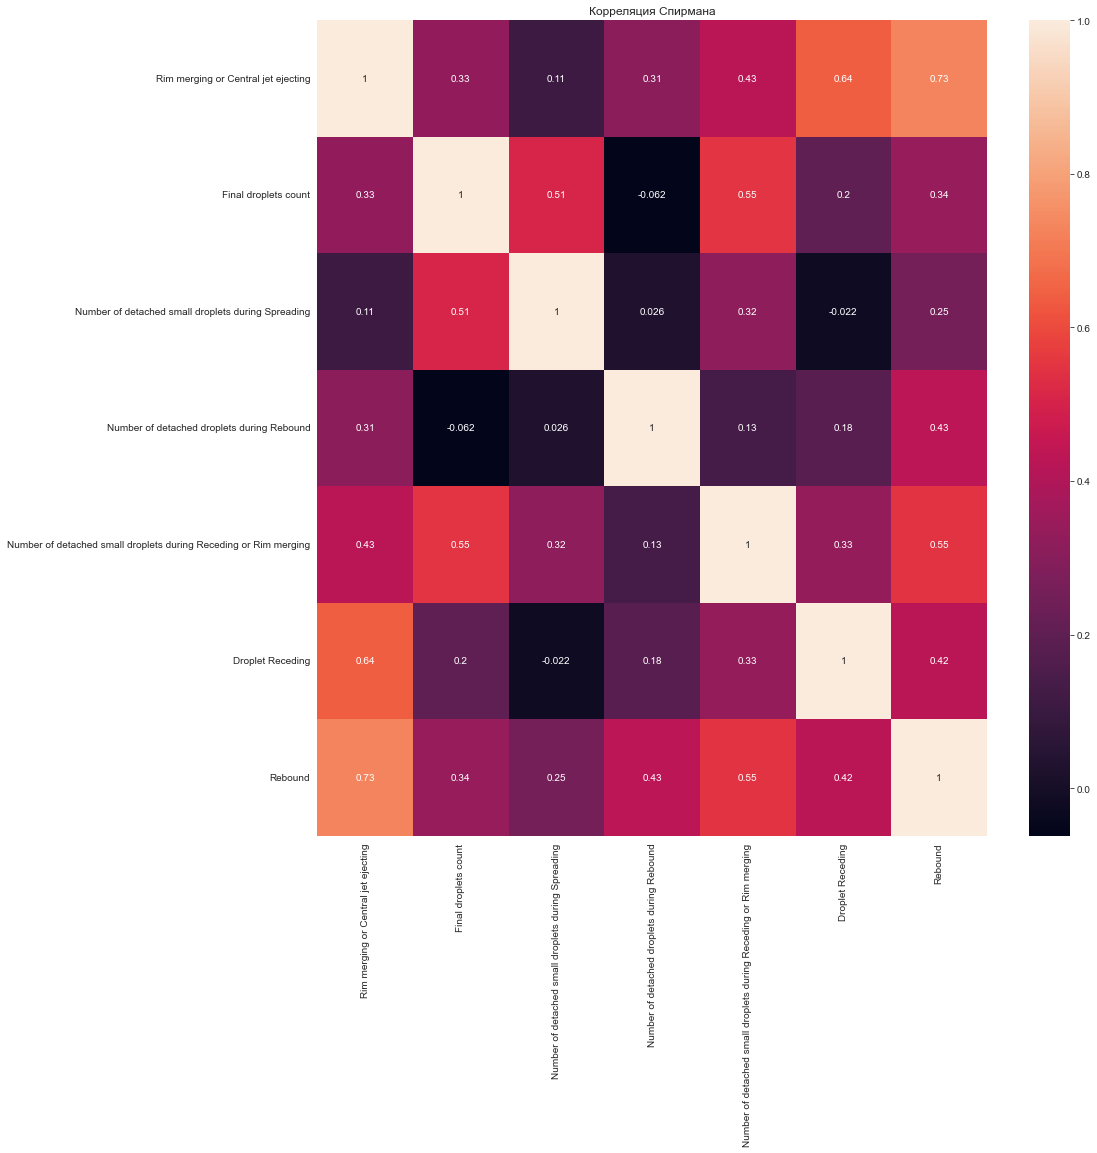

In [42]:
from scipy.stats import spearmanr as spearman

df_corr = df_temp[list(
        set(df_temp.columns) - {'Total number of dropped drops', 'Comments'}
    )
].copy()
corr_spearman = spearman(df_corr)[0]

fig, ax = plt.subplots(figsize=(15, 15)) 
sns.heatmap(corr_spearman, annot=True, xticklabels=df_corr.columns, yticklabels=df_corr.columns, ax=ax)
plt.title('Корреляция Спирмана')
plt.show()

In [44]:
df_corr.head()

,Rim merging or Central jet ejecting,Final droplets count,Number of detached small droplets during Spreading,Number of detached droplets during Rebound,Number of detached small droplets during Receding or Rim merging,Droplet Receding,Rebound
2,0.0,2.0,many,0.0,0.0,0.0,0.0
3,0.0,1.0,many,0.0,0.0,0.0,0.0
4,0.0,1.0,many,0.0,0.0,0.0,0.0
5,0.0,1.0,many,0.0,0.0,0.0,0.0
6,0.0,1.0,many,0.0,0.0,0.0,0.0


In [45]:
from scipy.stats import kendalltau

In [100]:
binary_columns = ['Rim merging or Central jet ejecting', 'Droplet Receding', 'Rebound']

df_corr_kend = df_corr[binary_columns].copy()
for column in binary_columns:
    df_corr_kend = df_corr_kend[df_corr_kend[column]!='-']
    df_corr_kend[df_corr_kend[column]!='0.0'] = 1
    df_corr_kend[column] = df_corr_kend[column].astype(float)

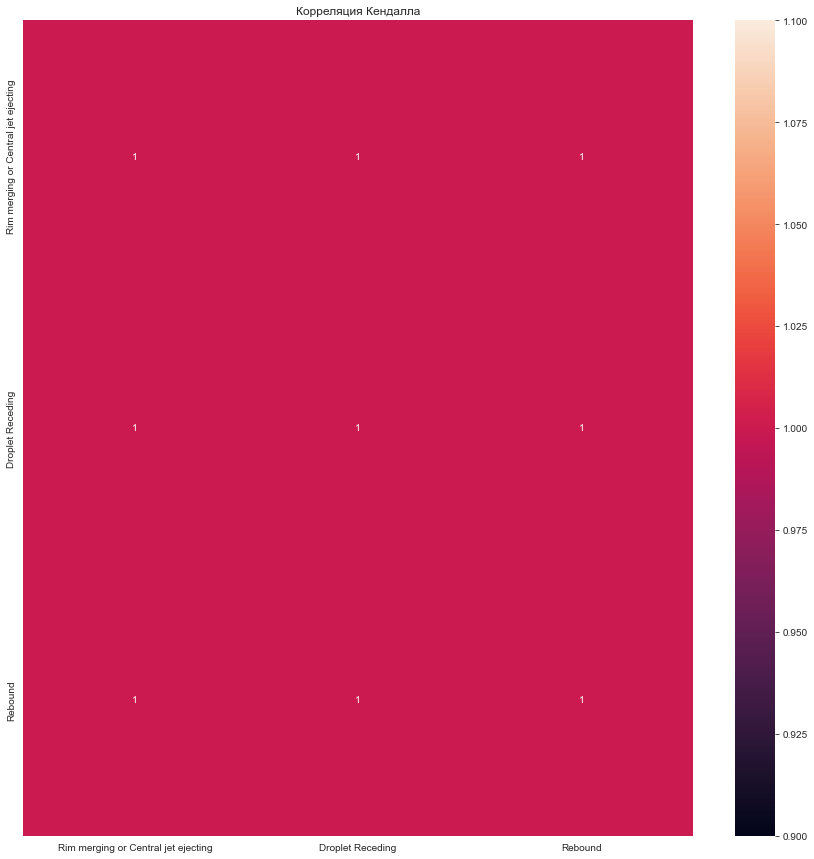

In [109]:
fig, ax = plt.subplots(figsize=(15, 15)) 
sns.heatmap(df_corr_kend.corr(method='kendall'), annot=True, ax=ax)
plt.title('Корреляция Кендалла')
plt.show()